# JP Morgan ML Take-Home Assignment

This notebook covers both requested deliverables:

1. A classification model to predict whether income is above or below $50k.
2. A customer segmentation model for marketing use.

## 1. Imports and Setup

In [ ]:
# ============================================================
# 1. Setup
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
TEST_SIZE = 0.2

## 2. Load the Data

The dataset comes with a separate file for column names, so we first reconstruct a clean DataFrame.

In [2]:
# My first goal here is simply to reconstruct a readable dataframe from the raw files.
# I do this explicitly instead of relying on default headers because the assignment
# provides the column names separately and I wanted the setup to stay reproducible.

# ============================================================
# 2. Load data
# Replace the file path if needed
# ============================================================
COLUMN_FILE = 'data/census-bureau.columns'
DATA_FILE = 'data/census-bureau.data'

def load_census_data(column_path=COLUMN_FILE, data_path=DATA_FILE):
    columns = pd.read_csv(column_path, header=None).iloc[:, 0].str.strip().tolist()
    df = pd.read_csv(data_path, header=None, names=columns)
    df.columns = [col.strip().lower().replace(' ', '_').replace("'", '') for col in df.columns]

    object_cols = df.select_dtypes(include='object').columns
    df[object_cols] = df[object_cols].apply(lambda col: col.str.strip())
    df = df.replace('?', np.nan)

    df['target'] = (df['label'].str.contains(r'50000\+', regex=True)).astype(int)
    return df


df = load_census_data()
print(f'Shape: {df.shape}')
display(df.head())

Shape: (199523, 43)


,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,enroll_in_edu_inst_last_wk,marital_stat,major_industry_code,major_occupation_code,...,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veterans_admin,veterans_benefits,weeks_worked_in_year,year,label,target
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.,0
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.,0
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.,0
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.,0
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.,0


In [3]:
# ============================================================
# 3. Create binary target
# The original label column is converted into a binary target:
# 1 = income > 50K, 0 = income <= 50K
# ============================================================

df = df.copy()

# Adjust this line if your label text is slightly different
df["target"] = (df["label"].astype(str).str.contains("50000\\+")).astype(int)

print(df["target"].value_counts(dropna=False))
print(df["target"].value_counts(normalize=True))

target
0    187141
1     12382
Name: count, dtype: int64
target
0    0.937942
1    0.062058
Name: proportion, dtype: float64


In [4]:
# ============================================================
# 4. Basic schema check
# ============================================================

print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes.value_counts())

missing_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean().round(4),
    "n_unique": df.nunique(dropna=True)
}).sort_values(["missing_count", "n_unique"], ascending=[False, False])

display(missing_summary.head(20))

Shape: (199523, 43)

Column types:
object     29
int64      13
float64     1
Name: count, dtype: int64


,dtype,missing_count,missing_pct,n_unique
migration_code-change_in_msa,object,99696,0.4997,9
migration_code-move_within_reg,object,99696,0.4997,9
migration_code-change_in_reg,object,99696,0.4997,8
migration_prev_res_in_sunbelt,object,99696,0.4997,3
country_of_birth_father,object,6713,0.0336,42
country_of_birth_mother,object,6119,0.0307,42
country_of_birth_self,object,3393,0.0170,42
hispanic_origin,object,874,0.0044,9
state_of_previous_residence,object,708,0.0035,50
weight,float64,0,0.0000,99800


In [5]:
# ============================================================
# 5. Keep a clean working copy
# ============================================================

df_model = df.copy()

## 3. Quick Data Audit

Target counts:
target
0    187141
1     12382
Name: count, dtype: int64

Target proportions:
target
0    0.937942
1    0.062058
Name: proportion, dtype: float64


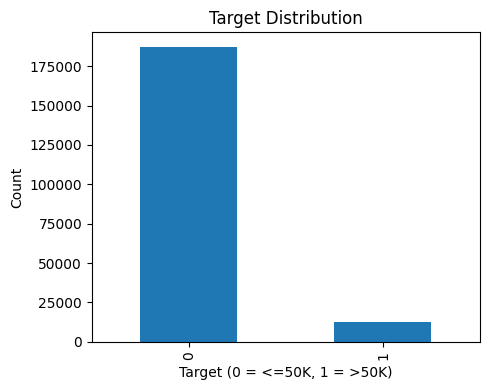

In [6]:
# ============================================================
# 6. Target distribution
# The positive class is relatively rare, so PR-AUC and F1
# will be especially important evaluation metrics.
# ============================================================

target_dist = df_model["target"].value_counts().sort_index()
target_prop = df_model["target"].value_counts(normalize=True).sort_index()

print("Target counts:")
print(target_dist)
print("\nTarget proportions:")
print(target_prop)

plt.figure(figsize=(5, 4))
target_dist.plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Target (0 = <=50K, 1 = >50K)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [7]:
# I use this quick summary to separate true missingness from fields that simply look messy.
# At this stage I am not fixing anything yet — I just want a high-level sense of where
# the data may need more careful treatment later in preprocessing.

# ============================================================
# 7. Missingness overview
# ============================================================

missing_summary = pd.DataFrame({
    "dtype": df_model.dtypes.astype(str),
    "missing_count": df_model.isna().sum(),
    "missing_pct": df_model.isna().mean(),
    "n_unique": df_model.nunique(dropna=True)
}).sort_values(["missing_count", "missing_pct"], ascending=[False, False])

display(missing_summary.head(20))

,dtype,missing_count,missing_pct,n_unique
migration_code-change_in_msa,object,99696,0.499672,9
migration_code-change_in_reg,object,99696,0.499672,8
migration_code-move_within_reg,object,99696,0.499672,9
migration_prev_res_in_sunbelt,object,99696,0.499672,3
country_of_birth_father,object,6713,0.033645,42
country_of_birth_mother,object,6119,0.030668,42
country_of_birth_self,object,3393,0.017006,42
hispanic_origin,object,874,0.004380,9
state_of_previous_residence,object,708,0.003548,50
age,int64,0,0.000000,91


In [8]:
# A lot of the categorical columns use placeholder values like "Not in universe".
# I did not want to blindly treat those as standard nulls, so I inspect them separately here.
# For this dataset, those placeholders often carry real meaning about eligibility or life stage.

# ============================================================
# 8. Inspect categorical placeholders
# Many census-like fields contain values such as
# 'Not in universe' that are not ordinary missing values.
# ============================================================

obj_cols = df_model.select_dtypes(include="object").columns.tolist()

suspicious_tokens = [
    "not in universe", "unknown", "?", "not known",
    "other", "none", "missing", "not applicable", "n/a"
]

rows = []
for col in obj_cols:
    vc = df_model[col].astype(str).str.strip().str.lower().value_counts(dropna=False)
    suspicious_found = [k for k in vc.index if any(tok in k for tok in suspicious_tokens)]
    rows.append({
        "column": col,
        "n_unique": df_model[col].nunique(dropna=True),
        "top_values": dict(vc.head(8)),
        "suspicious_values_found": suspicious_found[:10]
    })

obj_summary = pd.DataFrame(rows).sort_values("n_unique", ascending=False)
display(obj_summary)

,column,n_unique,top_values,suspicious_values_found
14,state_of_previous_residence,50,"{'not in universe': 183750, 'california': 1714...",[not in universe]
24,country_of_birth_mother,42,"{'united-states': 160479, 'mexico': 9781, 'nan...",[]
23,country_of_birth_father,42,"{'united-states': 159163, 'mexico': 10008, 'na...",[]
25,country_of_birth_self,42,"{'united-states': 176989, 'mexico': 5767, 'nan...",[]
15,detailed_household_and_family_stat,38,"{'householder': 53248, 'child <18 never marr n...","[other rel 18+ ever marr not in subfamily, oth..."
4,major_industry_code,24,"{'not in universe or children': 100684, 'retai...","[not in universe or children, other profession..."
1,education,17,"{'high school graduate': 48407, 'children': 47...",[]
5,major_occupation_code,15,"{'not in universe': 100684, 'adm support inclu...","[not in universe, other service]"
19,migration_code-move_within_reg,9,"{'nan': 99696, 'nonmover': 82538, 'same county...",[not in universe]
7,hispanic_origin,9,"{'all other': 171907, 'mexican-american': 8079...","[all other, other spanish]"


In [9]:
# ============================================================
# 9. Numeric profile
# Several numeric-looking fields are actually coded categories.
# ============================================================

num_cols = df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()

num_profile = pd.DataFrame({
    "column": num_cols,
    "n_unique": [df_model[c].nunique(dropna=True) for c in num_cols],
    "min": [df_model[c].min() for c in num_cols],
    "max": [df_model[c].max() for c in num_cols]
}).sort_values("n_unique")

display(num_profile)

,column,n_unique,min,max
12,year,2,94.00,95.0
13,target,2,0.00,1.0
10,veterans_benefits,3,0.00,2.0
9,own_business_or_self_employed,3,0.00,2.0
8,num_persons_worked_for_employer,7,0.00,6.0
2,detailed_occupation_recode,47,0.00,46.0
1,detailed_industry_recode,52,0.00,51.0
11,weeks_worked_in_year,53,0.00,52.0
0,age,91,0.00,90.0
5,capital_losses,113,0.00,4608.0


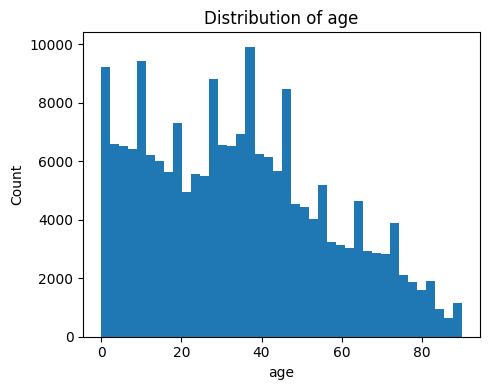

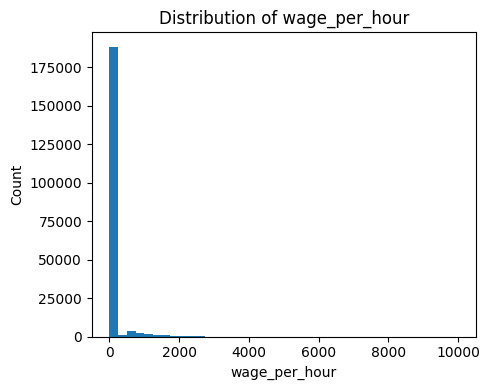

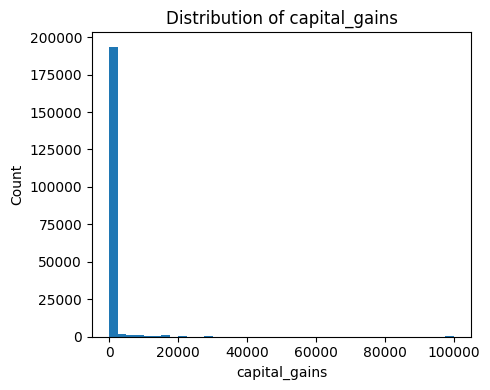

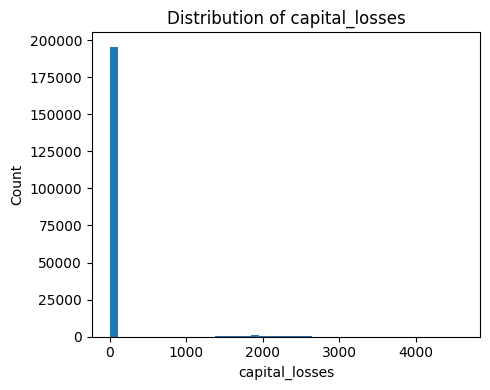

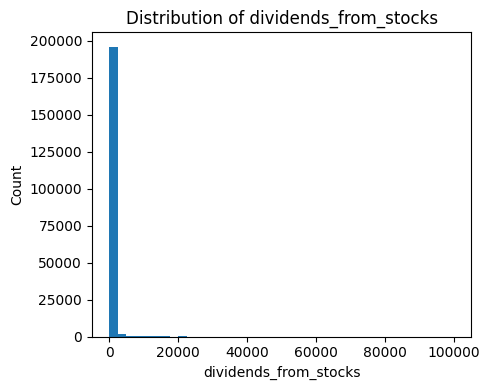

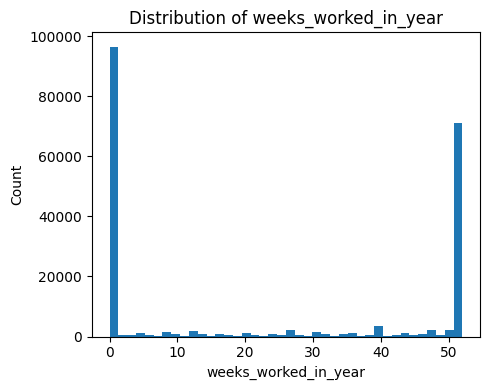

In [10]:
# ============================================================
# 10. A few quick numeric plots
# Keep the EDA concise and focused on variables likely related
# to income.
# ============================================================

eda_numeric_cols = [
    "age",
    "wage_per_hour",
    "capital_gains",
    "capital_losses",
    "dividends_from_stocks",
    "weeks_worked_in_year"
]

for col in eda_numeric_cols:
    plt.figure(figsize=(5, 4))
    plt.hist(df_model[col], bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [11]:
# ============================================================
# 11. Compare positive-class rates for a few suspicious fields
# This helps identify whether missingness or special values
# contain information.
# ============================================================

migration_cols = [
    "migration_code-change_in_msa",
    "migration_code-move_within_reg",
    "migration_code-change_in_reg",
    "migration_prev_res_in_sunbelt"
]

for col in migration_cols:
    print("=" * 80)
    print(col)
    print(df_model[col].value_counts(dropna=False).head(10))
    print("\nTarget rate by missingness:")
    print(df_model.groupby(df_model[col].isna())["target"].mean())
    print()

migration_code-change_in_msa
migration_code-change_in_msa
NaN                 99696
Nonmover            82538
MSA to MSA          10601
NonMSA to nonMSA     2811
Not in universe      1516
MSA to nonMSA         790
NonMSA to MSA         615
Abroad to MSA         453
Not identifiable      430
Abroad to nonMSA       73
Name: count, dtype: int64

Target rate by missingness:
migration_code-change_in_msa
False    0.058491
True     0.065630
Name: target, dtype: float64

migration_code-move_within_reg
migration_code-move_within_reg
NaN                             99696
Nonmover                        82538
Same county                      9812
Different county same state      2797
Not in universe                  1516
Different state in South          973
Different state in West           679
Different state in Midwest        551
Abroad                            530
Different state in Northeast      431
Name: count, dtype: int64

Target rate by missingness:
migration_code-move_within_reg
Fals

## 4. Classification Modeling - Logistic Regression

### Modeling choices

- I use a train/test split with stratification because the income classes are imbalanced.
- I keep the `weight` column available as a sample-weight feature for the classifier because the assignment notes that it reflects population representation.
- Categorical features are imputed and one-hot encoded.
- Numeric features are median-imputed and scaled.
- The main model is logistic regression because it is strong, fast, and easy to explain in a business-facing report.

### How I approached the feature space

Before I started fitting models, I paused here to clean up the feature types. A lot of the raw columns come from census-style data, so some fields look numeric at first glance but are really coded categories. I wanted to make that explicit before building any preprocessing pipeline, since treating those columns incorrectly would hurt both model quality and interpretability.

In [12]:
# I made these feature-type decisions before building the pipelines so the rest of the notebook
# would stay cleaner. In particular, I recast coded numeric fields as categorical whenever
# the values represented labels rather than a meaningful numeric scale.

# ============================================================
# 12. Feature design decisions
# - Keep structured placeholder categories as valid levels
# - Treat migration NaN as an explicit category
# - Recast coded numeric columns as categorical
# - Use a separate sample weight variable, not a predictor
# ============================================================

df_work = df_model.copy()

coded_numeric_cols = [
    "year",
    "veterans_benefits",
    "own_business_or_self_employed",
    "num_persons_worked_for_employer",
    "detailed_industry_recode",
    "detailed_occupation_recode"
]

continuous_numeric_cols = [
    "age",
    "wage_per_hour",
    "capital_gains",
    "capital_losses",
    "dividends_from_stocks",
    "weeks_worked_in_year"
]

migration_cols = [
    "migration_code-change_in_msa",
    "migration_code-move_within_reg",
    "migration_code-change_in_reg",
    "migration_prev_res_in_sunbelt"
]

# Explicitly encode structural missingness for migration variables
for col in migration_cols:
    df_work[col] = df_work[col].fillna("Missing")

# Recast coded numeric fields as categorical
for col in coded_numeric_cols:
    df_work[col] = df_work[col].astype(str)

In [13]:
# ============================================================
# 12. Feature design decisions
# - Keep structured placeholder categories as valid levels
# - Treat migration NaN as an explicit category
# - Recast coded numeric columns as categorical
# - Use a separate sample weight variable, not a predictor
# ============================================================

df_work = df_model.copy()

coded_numeric_cols = [
    "year",
    "veterans_benefits",
    "own_business_or_self_employed",
    "num_persons_worked_for_employer",
    "detailed_industry_recode",
    "detailed_occupation_recode"
]

continuous_numeric_cols = [
    "age",
    "wage_per_hour",
    "capital_gains",
    "capital_losses",
    "dividends_from_stocks",
    "weeks_worked_in_year"
]

migration_cols = [
    "migration_code-change_in_msa",
    "migration_code-move_within_reg",
    "migration_code-change_in_reg",
    "migration_prev_res_in_sunbelt"
]

# Explicitly encode structural missingness for migration variables
for col in migration_cols:
    df_work[col] = df_work[col].fillna("Missing")

# Recast coded numeric fields as categorical
for col in coded_numeric_cols:
    df_work[col] = df_work[col].astype(str)

In [14]:
# From this point on, I switch into a clean modeling dataset.
# I keep the original label, the binary target, and the survey weight conceptually separate
# because they play different roles in fitting and evaluation.

# ============================================================
# 13. Separate X, y, and sample weights
# Weight is kept for optional weighted training or evaluation,
# but is not used as a predictor.
# ============================================================

X = df_work.drop(columns=["label", "target"]).copy()
y = df_work["target"].copy()

sample_weight = X["weight"].copy() if "weight" in X.columns else pd.Series(np.ones(len(X)), index=X.index)
X = X.drop(columns=["weight"])

In [15]:
# I use one stratified split and keep it fixed across all models.
# That way, any performance difference I see later is much easier to attribute to the model
# itself rather than to a lucky or unlucky split.

# ============================================================
# 14. Train/test split
# ============================================================

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X,
    y,
    sample_weight,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Number of categorical features:", len(categorical_features))
print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Number of categorical features: 34
Categorical features:
['class_of_worker', 'detailed_industry_recode', 'detailed_occupation_recode', 'education', 'enroll_in_edu_inst_last_wk', 'marital_stat', 'major_industry_code', 'major_occupation_code', 'race', 'hispanic_origin', 'sex', 'member_of_a_labor_union', 'reason_for_unemployment', 'full_or_part_time_employment_stat', 'tax_filer_stat', 'region_of_previous_residence', 'state_of_previous_residence', 'detailed_household_and_family_stat', 'detailed_household_summary_in_household', 'migration_code-change_in_msa', 'migration_code-change_in_reg', 'migration_code-move_within_reg', 'live_in_this_house_1_year_ago', 'migration_prev_res_in_sunbelt', 'num_persons_worked_for_employer', 'family_members_under_18', 'country_of_birth_father', 'country_of_birth_mother', 'country_of_birth_self', 'citizenship', 'own_business_or_self_employed', 'fill_inc_questionnaire_for_veterans_admin', 'veterans_benefits', 'year']

Numeric features:
['age', 'wage_per_hour', 

In [16]:
# I keep a dedicated preprocessing function for linear models because they are more sensitive
# to scaling and to the exact encoding scheme. Wrapping this in a function makes it easier
# for me to tweak one design choice, such as min_frequency, without rewriting everything.

# ============================================================
# 15. Build preprocessors
# Logistic regression uses scaling for numeric features.
# Tree-based models do not need scaling.
# ============================================================

def build_preprocessor_for_linear(min_freq=0.01):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=min_freq))
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])


def build_preprocessor_for_tree(min_freq=0.01):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=min_freq))
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

### Why I wrapped the evaluation logic into a function

At this point, I knew I was going to compare several models under the same train/test split and the same reporting criteria. Instead of repeating the same scoring code over and over, I bundled the fitting, probability scoring, threshold search, and confusion-matrix extraction into one helper function. That made it much easier for me to compare models fairly and keep the notebook consistent.

In [17]:
# I bundled the repeated evaluation steps into one helper so I could compare models consistently.
# This function fits the pipeline, scores probabilities, searches for a threshold by F1,
# and then returns the exact metrics I need for both notebook analysis and report writing.

# ============================================================
# 16. Evaluation helper
# Returns ROC-AUC, PR-AUC, best threshold by F1, and confusion matrix
# ============================================================

def evaluate_model(pipe, X_train, y_train, X_test, y_test, sample_weight_train=None, use_weight=False):
    if use_weight and sample_weight_train is not None:
        pipe.fit(X_train, y_train, model__sample_weight=sample_weight_train)
    else:
        pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    best_precision = precisions[best_idx]
    best_recall = recalls[best_idx]

    y_pred = (y_prob >= best_threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "best_threshold": best_threshold,
        "best_f1": best_f1,
        "precision": best_precision,
        "recall": best_recall,
        "tn": cm[0, 0],
        "fp": cm[0, 1],
        "fn": cm[1, 0],
        "tp": cm[1, 1],
        "y_prob": y_prob,
        "y_pred": y_pred,
        "confusion_matrix": cm
    }

In [18]:
# ============================================================
# 15. Build preprocessors
# Logistic regression uses scaling for numeric features.
# Tree-based models do not need scaling.
# ============================================================

def build_preprocessor_for_linear(min_freq=0.01):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=min_freq))
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])


def build_preprocessor_for_tree(min_freq=0.01):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=min_freq))
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

In [19]:
# ============================================================
# 17. Baseline: Logistic Regression
# ============================================================

log_pipe = Pipeline([
    ("preprocessor", build_preprocessor_for_linear(min_freq=0.01)),
    ("model", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

log_results = evaluate_model(
    log_pipe,
    X_train, y_train,
    X_test, y_test,
    sample_weight_train=w_train,
    use_weight=False
)

pd.DataFrame([{
    "model": "LogisticRegression",
    "roc_auc": log_results["roc_auc"],
    "pr_auc": log_results["pr_auc"],
    "best_threshold": log_results["best_threshold"],
    "best_f1": log_results["best_f1"],
    "precision": log_results["precision"],
    "recall": log_results["recall"],
    "tn": log_results["tn"],
    "fp": log_results["fp"],
    "fn": log_results["fn"],
    "tp": log_results["tp"]
}])

,model,roc_auc,pr_auc,best_threshold,best_f1,precision,recall,tn,fp,fn,tp
0,LogisticRegression,0.945792,0.612175,0.26916,0.579379,0.548538,0.613893,36178,1251,956,1520


### Baseline model comparison

I did not want to jump straight to XGBoost without a reference point, so I first compared three models that play different roles:

- **Logistic Regression** as a simple and explainable baseline
- **Random Forest** as a strong non-linear tree baseline
- **XGBoost** as the more flexible boosted-tree option

My goal here was not just to pick the best metric mechanically, but to see whether the extra model complexity was actually buying me a meaningful performance gain.

In [20]:
# I start with side-by-side baseline models before I commit to a final recommendation.
# This helps me avoid overclaiming that the boosted model is best unless it clearly earns that spot.

# ============================================================
# 18. Compare multiple models
# ============================================================

model_results = []

# Logistic Regression
log_pipe = Pipeline([
    ("preprocessor", build_preprocessor_for_linear(min_freq=0.01)),
    ("model", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

res_log = evaluate_model(log_pipe, X_train, y_train, X_test, y_test, use_weight=False)
model_results.append({
    "model": "LogisticRegression",
    "roc_auc": res_log["roc_auc"],
    "pr_auc": res_log["pr_auc"],
    "best_threshold": res_log["best_threshold"],
    "best_f1": res_log["best_f1"],
    "precision": res_log["precision"],
    "recall": res_log["recall"],
    "tn": res_log["tn"],
    "fp": res_log["fp"],
    "fn": res_log["fn"],
    "tp": res_log["tp"]
})

# Random Forest
rf_pipe = Pipeline([
    ("preprocessor", build_preprocessor_for_tree(min_freq=0.01)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=16,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

res_rf = evaluate_model(rf_pipe, X_train, y_train, X_test, y_test, use_weight=False)
model_results.append({
    "model": "RandomForest",
    "roc_auc": res_rf["roc_auc"],
    "pr_auc": res_rf["pr_auc"],
    "best_threshold": res_rf["best_threshold"],
    "best_f1": res_rf["best_f1"],
    "precision": res_rf["precision"],
    "recall": res_rf["recall"],
    "tn": res_rf["tn"],
    "fp": res_rf["fp"],
    "fn": res_rf["fn"],
    "tp": res_rf["tp"]
})

# XGBoost
xgb_pipe = Pipeline([
    ("preprocessor", build_preprocessor_for_tree(min_freq=0.01)),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

res_xgb = evaluate_model(xgb_pipe, X_train, y_train, X_test, y_test, use_weight=False)
model_results.append({
    "model": "XGBoost",
    "roc_auc": res_xgb["roc_auc"],
    "pr_auc": res_xgb["pr_auc"],
    "best_threshold": res_xgb["best_threshold"],
    "best_f1": res_xgb["best_f1"],
    "precision": res_xgb["precision"],
    "recall": res_xgb["recall"],
    "tn": res_xgb["tn"],
    "fp": res_xgb["fp"],
    "fn": res_xgb["fn"],
    "tp": res_xgb["tp"]
})

model_results_df = pd.DataFrame(model_results).sort_values("best_f1", ascending=False)
model_results_df

,model,roc_auc,pr_auc,best_threshold,best_f1,precision,recall,tn,fp,fn,tp
2,XGBoost,0.956083,0.695148,0.292965,0.630499,0.616275,0.645396,36434,995,878,1598
1,RandomForest,0.949795,0.654142,0.247540,0.602520,0.571325,0.637318,36245,1184,898,1578
0,LogisticRegression,0.945792,0.612175,0.269160,0.579379,0.548538,0.613893,36178,1251,956,1520


### Narrow tuning after the baseline comparison

Once XGBoost emerged as the strongest candidate, I kept the follow-up tuning intentionally light. I was not trying to run a massive hyperparameter search in a take-home setting. Instead, I focused on a small design choice that mattered for sparse one-hot features: the `min_frequency` setting used in preprocessing. This let me check whether a slightly more permissive encoding improved recall and PR-AUC without turning the notebook into a tuning exercise.

In [21]:
# Once XGBoost looked strongest, I only did a narrow follow-up check here.
# I deliberately kept this tuning lightweight because I wanted the notebook to show judgment,
# not just a brute-force search over a huge parameter grid.

# ============================================================
# 19. Test how much rare-category grouping affects XGBoost
# ============================================================

xgb_minfreq_results = []

for mf in [0.01, 0.005]:
    pipe = Pipeline([
        ("preprocessor", build_preprocessor_for_tree(min_freq=mf)),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            gamma=0,
            reg_alpha=0,
            reg_lambda=1,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    res = evaluate_model(pipe, X_train, y_train, X_test, y_test, use_weight=False)
    xgb_minfreq_results.append({
        "min_frequency": mf,
        "roc_auc": res["roc_auc"],
        "pr_auc": res["pr_auc"],
        "best_threshold": res["best_threshold"],
        "best_f1": res["best_f1"],
        "precision": res["precision"],
        "recall": res["recall"],
        "tn": res["tn"],
        "fp": res["fp"],
        "fn": res["fn"],
        "tp": res["tp"]
    })

xgb_minfreq_df = pd.DataFrame(xgb_minfreq_results).sort_values("best_f1", ascending=False)
xgb_minfreq_df

,min_frequency,roc_auc,pr_auc,best_threshold,best_f1,precision,recall,tn,fp,fn,tp
1,0.005,0.955962,0.694819,0.286896,0.633509,0.612599,0.655897,36402,1027,852,1624
0,0.010,0.956083,0.695148,0.292965,0.630499,0.616275,0.645396,36434,995,878,1598


In [22]:
# This is the final training block I use to lock in the recommended model.
# After choosing the preprocessing and thresholding strategy, I refit the pipeline cleanly
# and store the outputs that I later reuse in the report figures.

# ============================================================
# 20. Final model
# Use the XGBoost configuration that gave the best F1.
# ============================================================

final_pipe = Pipeline([
    ("preprocessor", build_preprocessor_for_tree(min_freq=0.005)),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

final_results = evaluate_model(
    final_pipe,
    X_train, y_train,
    X_test, y_test,
    use_weight=False
)

pd.DataFrame([{
    "model": "Final_XGBoost",
    "roc_auc": final_results["roc_auc"],
    "pr_auc": final_results["pr_auc"],
    "best_threshold": final_results["best_threshold"],
    "best_f1": final_results["best_f1"],
    "precision": final_results["precision"],
    "recall": final_results["recall"],
    "tn": final_results["tn"],
    "fp": final_results["fp"],
    "fn": final_results["fn"],
    "tp": final_results["tp"]
}])

,model,roc_auc,pr_auc,best_threshold,best_f1,precision,recall,tn,fp,fn,tp
0,Final_XGBoost,0.955962,0.694819,0.286896,0.633509,0.612599,0.655897,36402,1027,852,1624


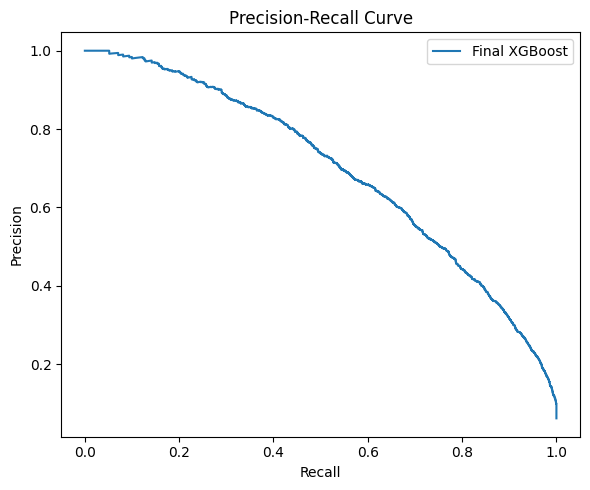

In [23]:
# ============================================================
# 21. Precision-recall curve for the final model
# ============================================================

y_prob_final = final_results["y_prob"]

precisions, recalls, _ = precision_recall_curve(y_test, y_prob_final)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, label="Final XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

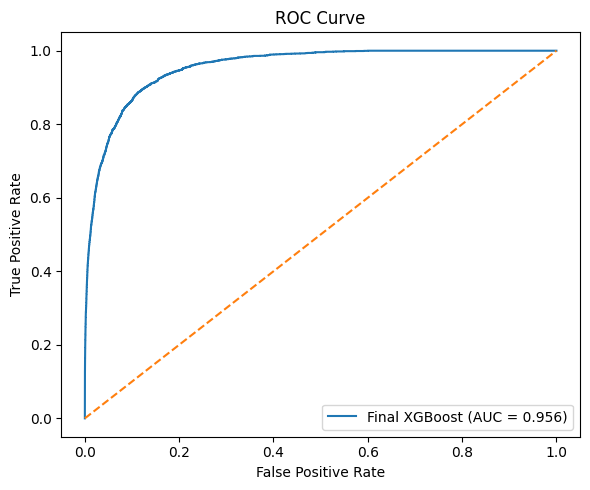

In [24]:
# ============================================================
# 22. ROC curve for the final model
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_prob_final)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Final XGBoost (AUC = {final_results['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

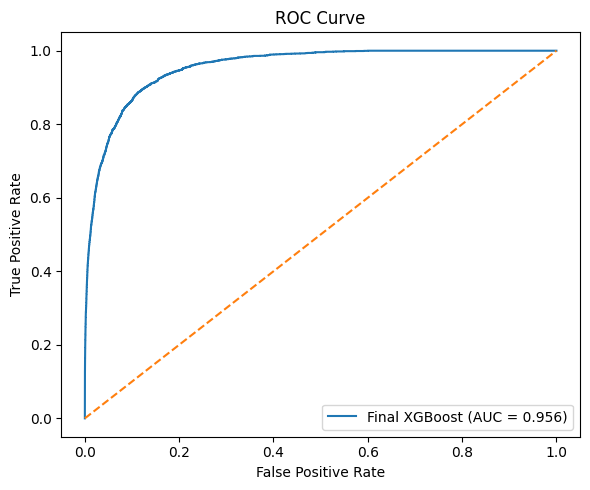

In [25]:
# ============================================================
# 22. ROC curve for the final model
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_prob_final)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Final XGBoost (AUC = {final_results['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# I combine the key outputs into one summary table so I can reuse the same results in multiple places.
# This cell is mostly for reporting convenience rather than core modeling logic.

# ============================================================
# 24. Final summary table
# ============================================================

summary_df = pd.concat([
    model_results_df.assign(section="Model comparison"),
    xgb_minfreq_df.assign(section="XGBoost min_frequency test")
], ignore_index=True)

summary_df

,model,roc_auc,pr_auc,best_threshold,best_f1,precision,recall,tn,fp,fn,tp,section,min_frequency
0,XGBoost,0.956083,0.695148,0.292965,0.630499,0.616275,0.645396,36434,995,878,1598,Model comparison,NaN
1,RandomForest,0.949795,0.654142,0.247540,0.602520,0.571325,0.637318,36245,1184,898,1578,Model comparison,NaN
2,LogisticRegression,0.945792,0.612175,0.269160,0.579379,0.548538,0.613893,36178,1251,956,1520,Model comparison,NaN
3,NaN,0.955962,0.694819,0.286896,0.633509,0.612599,0.655897,36402,1027,852,1624,XGBoost min_frequency test,0.005
4,NaN,0.956083,0.695148,0.292965,0.630499,0.616275,0.645396,36434,995,878,1598,XGBoost min_frequency test,0.010


### Turning the modeling results into report-ready outputs

From here on, the remaining cells are mostly about packaging the results into tables and visuals that I could use in the written report. A few of these cells overlap with one another because I tried more than one way to present the same result. I kept those iterations on purpose so the reader can still see how I refined the final reporting view.

In [27]:
# I re-import plotting libraries here on purpose so this reporting section is self-contained.
# Some of the cells below overlap with one another because I tried several layouts while deciding
# how I wanted to present the final results in the write-up.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

viz_df = summary_df.copy()

# Fill model names for the min_frequency experiment rows
mask = viz_df["model"].isna() & (viz_df["section"] == "XGBoost min_frequency test")
viz_df.loc[mask, "model"] = "XGBoost"

# Create a display label for plotting
viz_df["display_name"] = viz_df["model"].astype(str)

mf_mask = viz_df["section"] == "XGBoost min_frequency test"
viz_df.loc[mf_mask, "display_name"] = (
    viz_df.loc[mf_mask, "model"] + " (min_freq=" + viz_df.loc[mf_mask, "min_frequency"].astype(str) + ")"
)

display(viz_df)

,model,roc_auc,pr_auc,best_threshold,best_f1,precision,recall,tn,fp,fn,tp,section,min_frequency,display_name
0,XGBoost,0.956083,0.695148,0.292965,0.630499,0.616275,0.645396,36434,995,878,1598,Model comparison,NaN,XGBoost
1,RandomForest,0.949795,0.654142,0.247540,0.602520,0.571325,0.637318,36245,1184,898,1578,Model comparison,NaN,RandomForest
2,LogisticRegression,0.945792,0.612175,0.269160,0.579379,0.548538,0.613893,36178,1251,956,1520,Model comparison,NaN,LogisticRegression
3,XGBoost,0.955962,0.694819,0.286896,0.633509,0.612599,0.655897,36402,1027,852,1624,XGBoost min_frequency test,0.005,XGBoost (min_freq=0.005)
4,XGBoost,0.956083,0.695148,0.292965,0.630499,0.616275,0.645396,36434,995,878,1598,XGBoost min_frequency test,0.010,XGBoost (min_freq=0.01)


In [28]:
# This cell is very similar to the previous plotting block.
# I kept it because I used it while iterating on figure layout and captions, but in practice
# I only needed one final version for the report.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

viz_df = summary_df.copy()

# Fill model names for the min_frequency experiment rows
mask = viz_df["model"].isna() & (viz_df["section"] == "XGBoost min_frequency test")
viz_df.loc[mask, "model"] = "XGBoost"

# Create a display label for plotting
viz_df["display_name"] = viz_df["model"].astype(str)

mf_mask = viz_df["section"] == "XGBoost min_frequency test"
viz_df.loc[mf_mask, "display_name"] = (
    viz_df.loc[mf_mask, "model"] + " (min_freq=" + viz_df.loc[mf_mask, "min_frequency"].astype(str) + ")"
)

display(viz_df)

,model,roc_auc,pr_auc,best_threshold,best_f1,precision,recall,tn,fp,fn,tp,section,min_frequency,display_name
0,XGBoost,0.956083,0.695148,0.292965,0.630499,0.616275,0.645396,36434,995,878,1598,Model comparison,NaN,XGBoost
1,RandomForest,0.949795,0.654142,0.247540,0.602520,0.571325,0.637318,36245,1184,898,1578,Model comparison,NaN,RandomForest
2,LogisticRegression,0.945792,0.612175,0.269160,0.579379,0.548538,0.613893,36178,1251,956,1520,Model comparison,NaN,LogisticRegression
3,XGBoost,0.955962,0.694819,0.286896,0.633509,0.612599,0.655897,36402,1027,852,1624,XGBoost min_frequency test,0.005,XGBoost (min_freq=0.005)
4,XGBoost,0.956083,0.695148,0.292965,0.630499,0.616275,0.645396,36434,995,878,1598,XGBoost min_frequency test,0.010,XGBoost (min_freq=0.01)


In [29]:
# This is a small helper block for turning the summary table back into figure inputs.
# I kept it separate because it made the later plotting cells easier for me to tweak.

# Select best row by F1
best_row = viz_df.sort_values("best_f1", ascending=False).iloc[0]

cm = np.array([
    [best_row["tn"], best_row["fp"]],
    [best_row["fn"], best_row["tp"]]
], dtype=int)

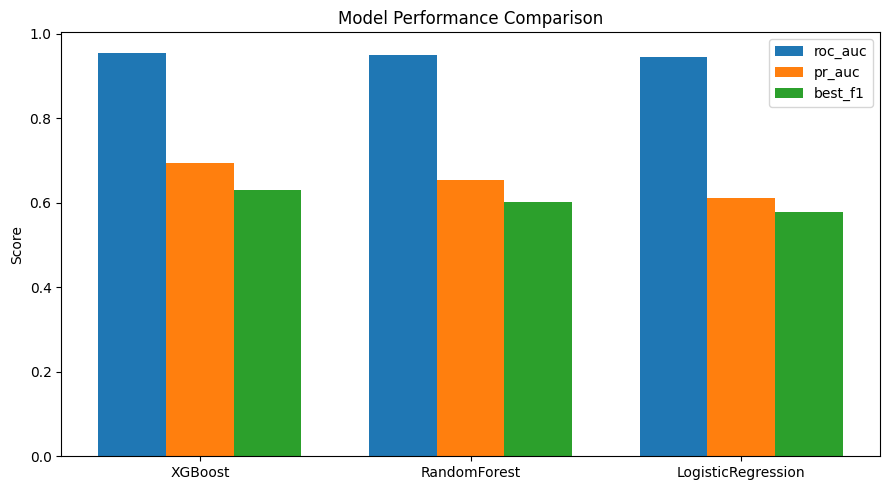

,model,roc_auc,pr_auc,best_f1,precision,recall
0,XGBoost,0.956083,0.695148,0.630499,0.616275,0.645396
1,RandomForest,0.949795,0.654142,0.602520,0.571325,0.637318
2,LogisticRegression,0.945792,0.612175,0.579379,0.548538,0.613893


In [30]:
# From here on I am mostly experimenting with different report-style comparisons.
# These cells are somewhat redundant with one another, but I am keeping them so the notebook
# still shows the path I took before settling on the final visuals.

model_comp_df = viz_df[viz_df["section"] == "Model comparison"].copy()
model_comp_df = model_comp_df.sort_values("best_f1", ascending=False)

metrics_to_plot = ["roc_auc", "pr_auc", "best_f1"]

x = np.arange(len(model_comp_df))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + (i - 1) * width, model_comp_df[metric], width=width, label=metric)

ax.set_xticks(x)
ax.set_xticklabels(model_comp_df["model"], rotation=0)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.legend()

plt.tight_layout()
plt.show()

display(model_comp_df[["model", "roc_auc", "pr_auc", "best_f1", "precision", "recall"]])

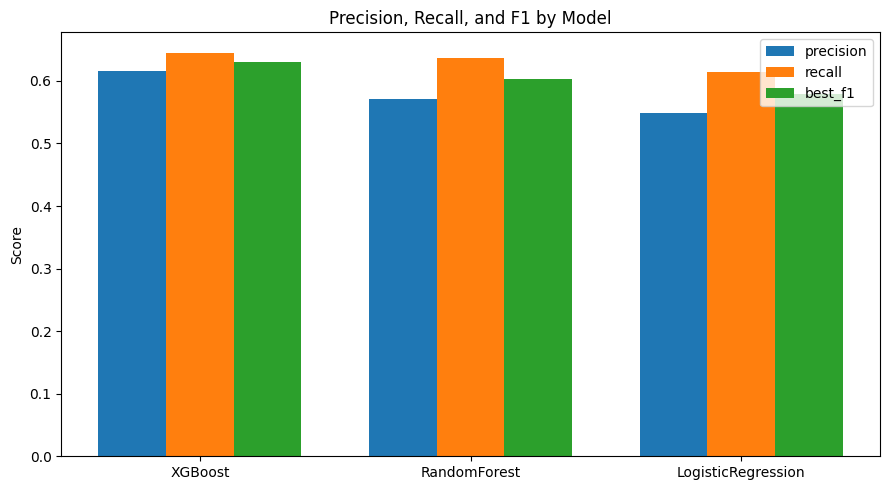

In [31]:
# This is another comparison view built from the same summary table.
# I did not end up needing every version, but I left them here because they helped me check
# whether the ranking between models stayed stable across different metrics.

metrics_to_plot = ["precision", "recall", "best_f1"]

x = np.arange(len(model_comp_df))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + (i - 1) * width, model_comp_df[metric], width=width, label=metric)

ax.set_xticks(x)
ax.set_xticklabels(model_comp_df["model"])
ax.set_ylabel("Score")
ax.set_title("Precision, Recall, and F1 by Model")
ax.legend()

plt.tight_layout()
plt.show()

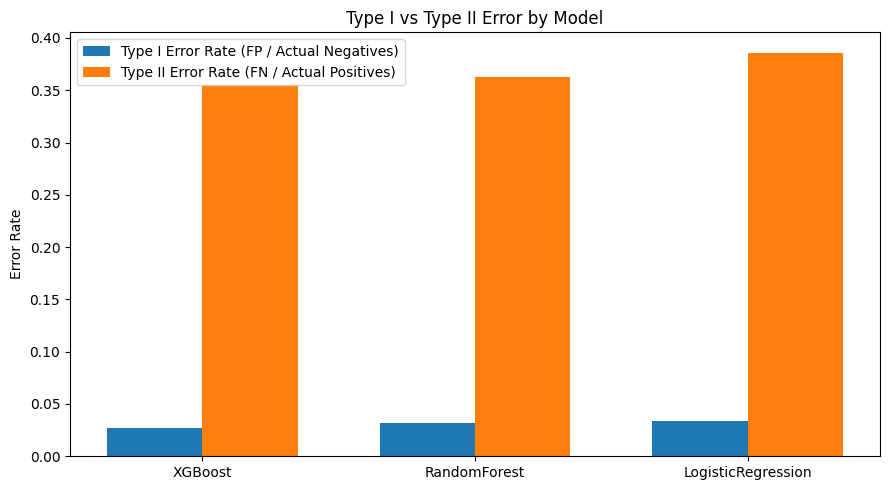

,model,type1_error_rate,type2_error_rate,fp,fn
0,XGBoost,0.026584,0.354604,995,878
1,RandomForest,0.031633,0.362682,1184,898
2,LogisticRegression,0.033423,0.386107,1251,956


In [32]:
# Here I reshape the same model comparison results into error-style metrics.
# It overlaps with the earlier comparison plots, so I now treat it as optional supporting work.

model_comp_df = model_comp_df.copy()

model_comp_df["type1_error_rate"] = model_comp_df["fp"] / (model_comp_df["fp"] + model_comp_df["tn"])
model_comp_df["type2_error_rate"] = model_comp_df["fn"] / (model_comp_df["fn"] + model_comp_df["tp"])

x = np.arange(len(model_comp_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, model_comp_df["type1_error_rate"], width=width, label="Type I Error Rate (FP / Actual Negatives)")
ax.bar(x + width/2, model_comp_df["type2_error_rate"], width=width, label="Type II Error Rate (FN / Actual Positives)")

ax.set_xticks(x)
ax.set_xticklabels(model_comp_df["model"])
ax.set_ylabel("Error Rate")
ax.set_title("Type I vs Type II Error by Model")
ax.legend()

plt.tight_layout()
plt.show()

display(model_comp_df[["model", "type1_error_rate", "type2_error_rate", "fp", "fn"]])

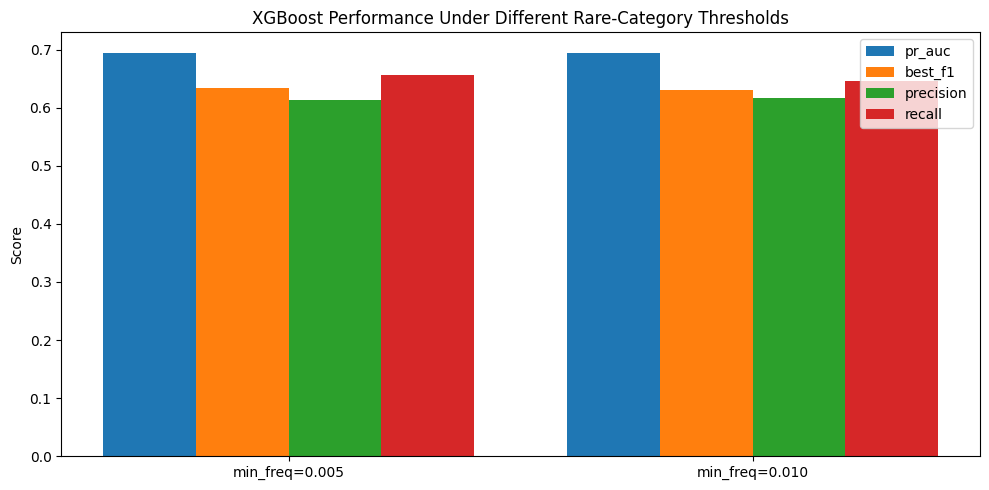

,display_name,roc_auc,pr_auc,best_f1,precision,recall
3,XGBoost (min_freq=0.005),0.955962,0.694819,0.633509,0.612599,0.655897
4,XGBoost (min_freq=0.01),0.956083,0.695148,0.630499,0.616275,0.645396


In [33]:
# This plot is more diagnostic than essential.
# I used it to sanity-check that my preprocessing choice was helping for the right reasons,
# even though only a subset of these visuals made it into the final report.

xgb_freq_df = viz_df[viz_df["section"] == "XGBoost min_frequency test"].copy()
xgb_freq_df = xgb_freq_df.sort_values("min_frequency")

metrics_to_plot = ["pr_auc", "best_f1", "precision", "recall"]

x = np.arange(len(xgb_freq_df))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + (i - 1.5) * width, xgb_freq_df[metric], width=width, label=metric)

ax.set_xticks(x)
ax.set_xticklabels([f"min_freq={mf:.3f}" for mf in xgb_freq_df["min_frequency"]])
ax.set_ylabel("Score")
ax.set_title("XGBoost Performance Under Different Rare-Category Thresholds")
ax.legend()

plt.tight_layout()
plt.show()

display(xgb_freq_df[["display_name", "roc_auc", "pr_auc", "best_f1", "precision", "recall"]])

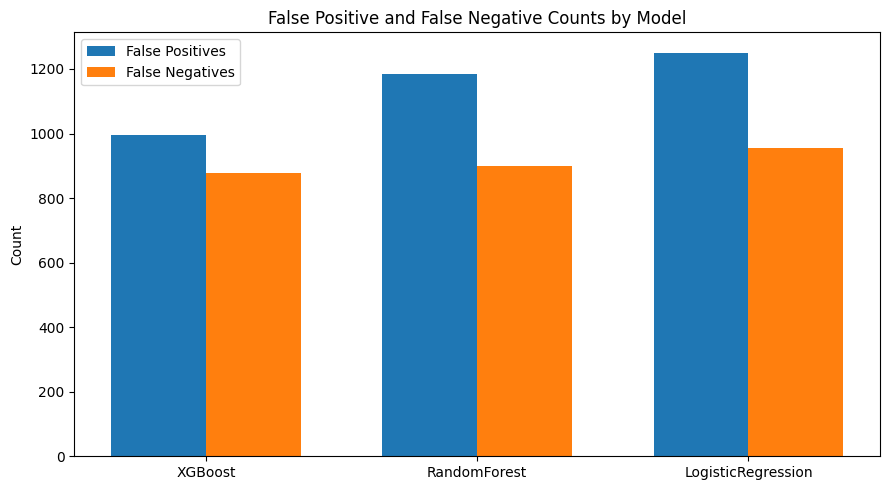

In [34]:
# This is another draft view for the model comparison section.
# It is somewhat repetitive, but I am leaving it in place because it reflects how I iterated
# before deciding which figure was the cleanest to keep.

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(model_comp_df))
width = 0.35

ax.bar(x - width/2, model_comp_df["fp"], width=width, label="False Positives")
ax.bar(x + width/2, model_comp_df["fn"], width=width, label="False Negatives")

ax.set_xticks(x)
ax.set_xticklabels(model_comp_df["model"])
ax.set_ylabel("Count")
ax.set_title("False Positive and False Negative Counts by Model")
ax.legend()

plt.tight_layout()
plt.show()

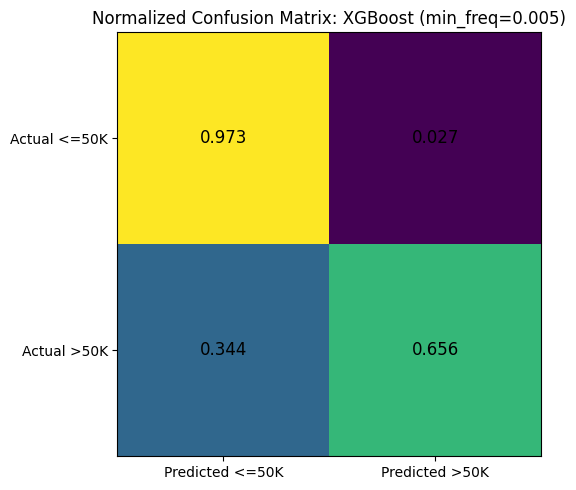

In [35]:
# This is another reporting cell that overlaps with earlier plotting work.
# I am leaving it here because it was part of how I iterated on the confusion-matrix presentation.

cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted <=50K", "Predicted >50K"])
ax.set_yticklabels(["Actual <=50K", "Actual >50K"])
ax.set_title(f"Normalized Confusion Matrix: {best_row['display_name']}")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm_norm[i, j]:.3f}", ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.show()

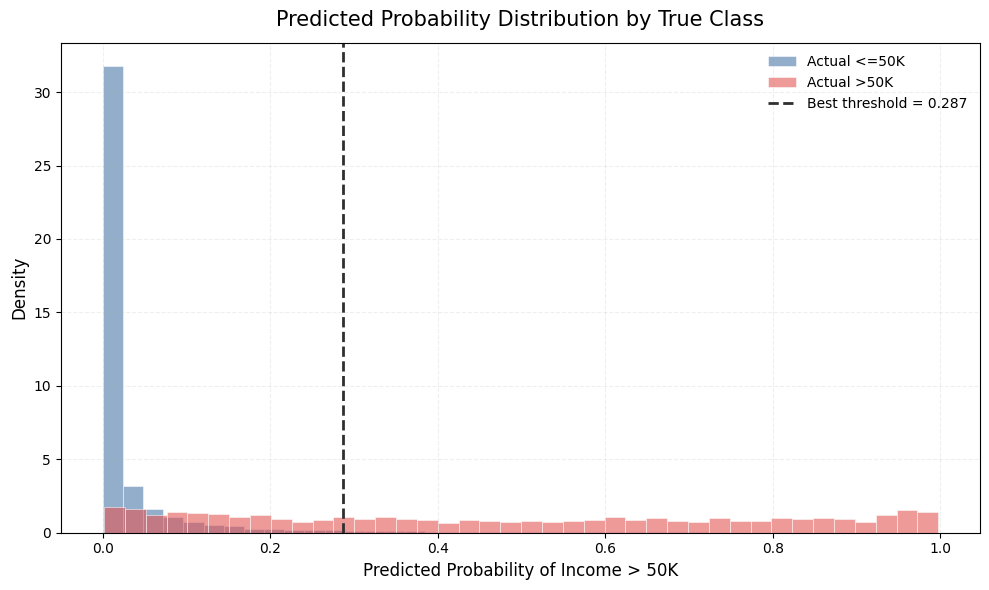

In [36]:
# I kept this section in notebook-style scratch format because I originally used it
# to test report figures quickly. It overlaps with earlier cells, so I now treat it as
# optional supporting work rather than the main analysis path.

# %%
# ============================================================
# PREDICTED PROBABILITY DISTRIBUTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 假設你已經有：
# y_test
# final_results["y_prob"]
# final_results["best_threshold"]

y_prob_final = final_results["y_prob"]
best_threshold = final_results["best_threshold"]

prob_df = pd.DataFrame({
    "y_true": np.asarray(y_test),
    "y_prob": np.asarray(y_prob_final)
})

neg_probs = prob_df.loc[prob_df["y_true"] == 0, "y_prob"]
pos_probs = prob_df.loc[prob_df["y_true"] == 1, "y_prob"]

plt.figure(figsize=(10, 6))

# Professional colors
color_neg = "#4C78A8"   # muted blue
color_pos = "#E45756"   # muted red
threshold_color = "#2F2F2F"

plt.hist(
    neg_probs,
    bins=40,
    density=True,
    alpha=0.60,
    label="Actual <=50K",
    color=color_neg,
    edgecolor="white",
    linewidth=0.6
)

plt.hist(
    pos_probs,
    bins=40,
    density=True,
    alpha=0.60,
    label="Actual >50K",
    color=color_pos,
    edgecolor="white",
    linewidth=0.6
)

plt.axvline(
    best_threshold,
    color=threshold_color,
    linestyle="--",
    linewidth=2,
    label=f"Best threshold = {best_threshold:.3f}"
)

plt.title("Predicted Probability Distribution by True Class", fontsize=15, pad=12)
plt.xlabel("Predicted Probability of Income > 50K", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(frameon=False)
plt.grid(alpha=0.2, linestyle="--")
plt.tight_layout()
plt.show()

In [37]:
final_results

{'roc_auc': 0.9559618715473402,
 'pr_auc': 0.694818829892732,
 'best_threshold': np.float32(0.28689602),
 'best_f1': np.float64(0.6335088740861101),
 'precision': np.float64(0.6125990192380234),
 'recall': np.float64(0.6558966074313409),
 'tn': np.int64(36402),
 'fp': np.int64(1027),
 'fn': np.int64(852),
 'tp': np.int64(1624),
 'y_prob': array([5.9758375e-05, 3.3691670e-03, 1.0808577e-03, ..., 1.0520163e-02,
        1.4930086e-03, 9.3017705e-03], shape=(39905,), dtype=float32),
 'y_pred': array([0, 0, 0, ..., 0, 0, 0], shape=(39905,)),
 'confusion_matrix': array([[36402,  1027],
        [  852,  1624]])}

In [38]:
# This was another scratch-area version of the reporting workflow.
# I did not delete it because it still documents part of the path I took while refining the outputs.

# # %%
# # ============================================================
# # TOP FEATURE IMPORTANCE
# # ============================================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

preprocessor = final_pipe.named_steps["preprocessor"]
final_model = final_pipe.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
importances = final_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

importance_df = importance_df.sort_values("importance", ascending=False).head(15)
importance_df = importance_df.sort_values("importance", ascending=True)

# plt.figure(figsize=(10, 7))

# bar_color = "#4C78A8"

# plt.barh(
#     importance_df["feature"],
#     importance_df["importance"],
#     color=bar_color,
#     alpha=0.9
# )

# plt.title("Top 15 Feature Importances (XGBoost)", fontsize=15, pad=12)
# plt.xlabel("Importance", fontsize=12)
# plt.ylabel("")
# plt.grid(axis="x", alpha=0.2, linestyle="--")
# plt.tight_layout()
# plt.show()

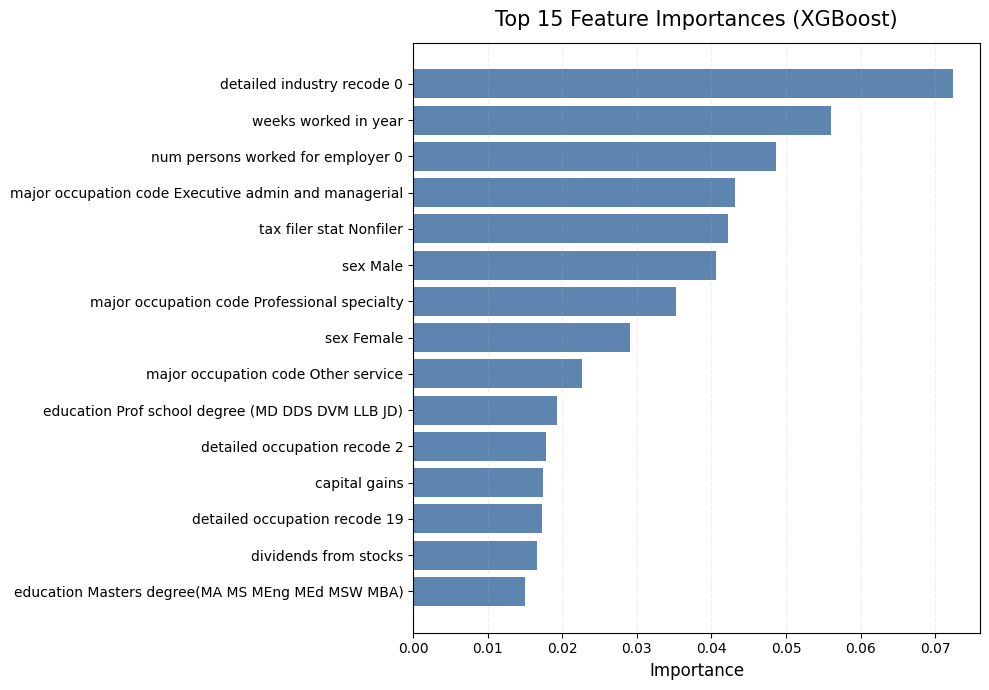

In [39]:
# This block is also mostly report-polishing work rather than new analysis.
# It overlaps with earlier figure-generation code, so I would treat it as optional if I were cleaning
# the notebook further for a final handoff.

# %%
# ============================================================
# CLEAN FEATURE NAMES FOR DISPLAY
# ============================================================

def clean_feature_name(name):
    name = name.replace("num__", "")
    name = name.replace("cat__", "")
    name = name.replace("remainder__", "")
    name = name.replace("_", " ")
    return name

importance_df["feature"] = importance_df["feature"].apply(clean_feature_name)

plt.figure(figsize=(10, 7))
plt.barh(
    importance_df["feature"],
    importance_df["importance"],
    color="#4C78A8",
    alpha=0.9
)

plt.title("Top 15 Feature Importances (XGBoost)", fontsize=15, pad=12)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("")
plt.grid(axis="x", alpha=0.2, linestyle="--")
plt.tight_layout()
plt.show()

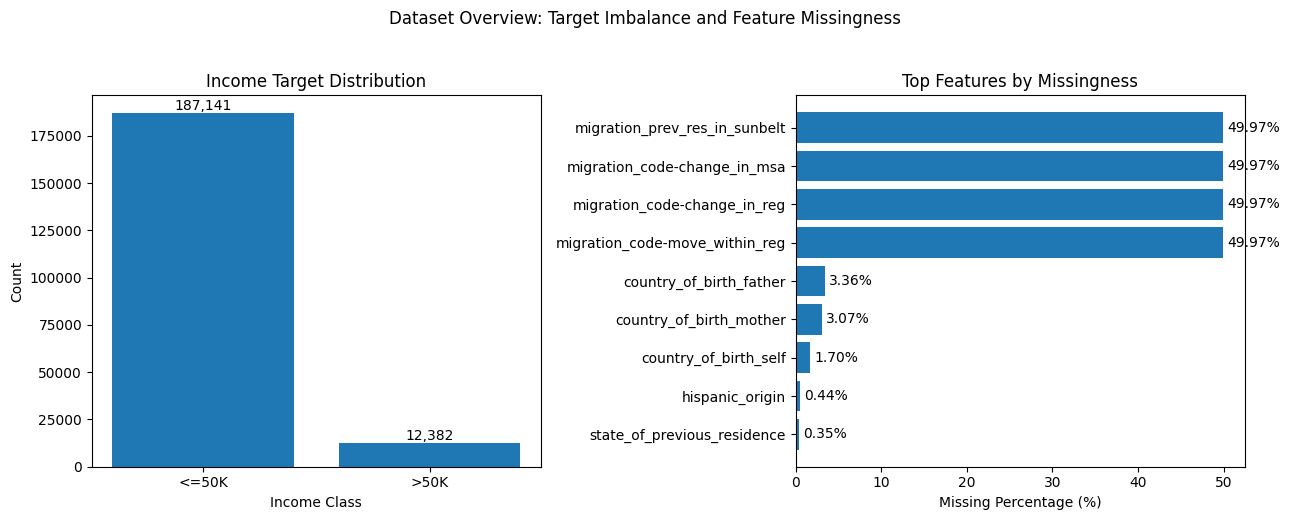

In [40]:
# This block is mainly for an alternate report figure.
# It is somewhat redundant with the earlier plotting section, but I kept it because it documents
# one of the intermediate versions I used while refining the final deliverables.

import pandas as pd
import matplotlib.pyplot as plt

# Assume df_model already exists
# If not, replace df_model with your cleaned dataframe name, e.g. df

plot_df = df_model.copy()

# -------- Panel 1: target distribution --------
target_counts = plot_df["target"].value_counts().sort_index()

# -------- Panel 2: top missing features --------
missing_pct = (
    plot_df.isna().mean()
    .sort_values(ascending=False)
)

missing_pct = missing_pct[missing_pct > 0].head(10)

# -------- Combined figure --------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: target distribution
axes[0].bar(
    ["<=50K", ">50K"],
    target_counts.values
)
axes[0].set_title("Income Target Distribution")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Income Class")

for i, v in enumerate(target_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

# Right: missingness
axes[1].barh(
    missing_pct.index[::-1],
    missing_pct.values[::-1] * 100
)
axes[1].set_title("Top Features by Missingness")
axes[1].set_xlabel("Missing Percentage (%)")

for i, v in enumerate((missing_pct.values[::-1] * 100)):
    axes[1].text(v + 0.5, i, f"{v:.2f}%", va="center")

plt.suptitle("Dataset Overview: Target Imbalance and Feature Missingness", y=1.03)
plt.tight_layout()
plt.show()

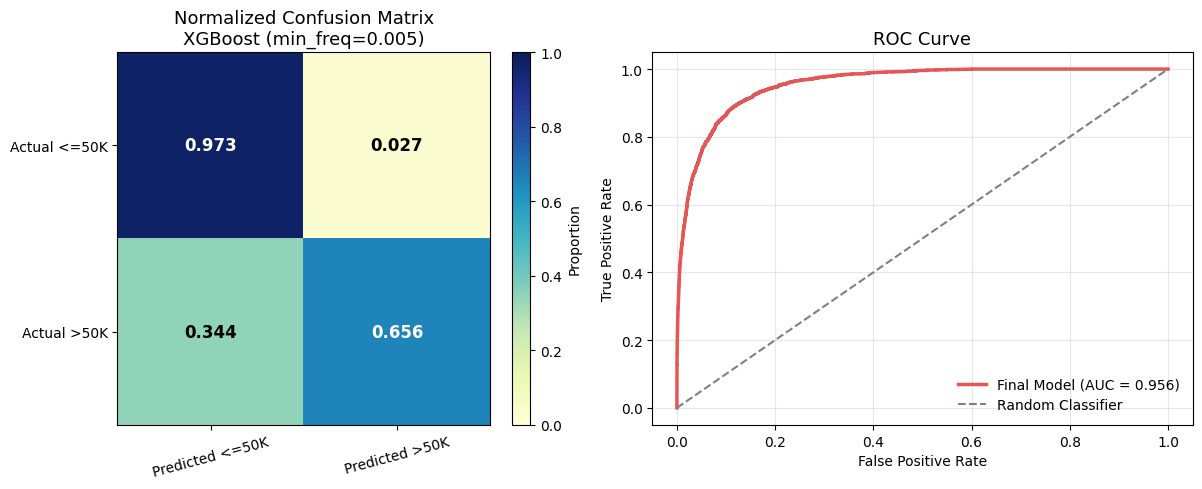

In [41]:
# This final figure cell overlaps with earlier ROC / confusion-matrix code.
# I kept it instead of deleting it because it shows the version I used when polishing the figure export.

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Normalize confusion matrix
cm_norm = cm / cm.sum(axis=1, keepdims=True)

# ROC values
fpr, tpr, _ = roc_curve(y_test, y_prob_final)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ============================================================
# Left: Normalized Confusion Matrix
# ============================================================
ax = axes[0]
im = ax.imshow(cm_norm, cmap="YlGnBu", vmin=0, vmax=1)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted <=50K", "Predicted >50K"], rotation=15)
ax.set_yticklabels(["Actual <=50K", "Actual >50K"])
ax.set_title(f"Normalized Confusion Matrix\n{best_row['display_name']}", fontsize=13)

for i in range(2):
    for j in range(2):
        val = cm_norm[i, j]
        ax.text(
            j, i, f"{val:.3f}",
            ha="center", va="center",
            fontsize=12,
            color="white" if val > 0.5 else "black",
            fontweight="bold"
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Proportion", rotation=90)

# ============================================================
# Right: ROC Curve
# ============================================================
ax2 = axes[1]
ax2.plot(fpr, tpr, linewidth=2.5, label=f"Final Model (AUC = {final_results['roc_auc']:.3f})", color="#E45756")
ax2.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, color="gray", label="Random Classifier")

ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve", fontsize=13)
ax2.legend(frameon=False)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()